In [4]:
!pip install snowflake-connector-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.8/84.8 kB 1.2 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of pyopenssl to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.0/105.0 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 52.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 66.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.8/55.8 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 7.0 MB/s eta 0:00:00
  Attempting uninstall: cryptography
    Found existing installation: cryptography 43.0.3
    Uninstalling cryptography-43.0.3:
      Successfully uninstalled cryptography-43.0.3
  Attempting uninstall: pyOpenSSL
    Found e

In [5]:
import snowflake.connector
nn = snowflake.connector.connect(
    user='DHARSHAAN21',
    password='Dharshaan@2120',
    account='lo31175.ap-southeast-5.aws',
    warehouse='COMPUTE_WH',
    database='DB2',
    schema='DB2.PUBLIC.WATER_PORTABILITY'
)

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sql_query = "SELECT * FROM WATER_PORTABILITY;"
df=pd.read_sql(sql_query,nn)
df


/tmp/ipykernel_1492/202779238.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df=pd.read_sql(sql_query,nn)


,PH,HARDNESS,SOLIDS,CHLORAMINES,SULFATE,CONDUCTIVITY,ORGANIC_CARBON,TRIHALOMETHANES,TURBIDITY,POTABILITY
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
...,...,...,...,...,...,...,...,...,...,...
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1
3272,7.808856,193.553212,17329.802160,8.061362,NaN,392.449580,19.903225,NaN,2.798243,1
3273,9.419510,175.762646,33155.578218,7.350233,NaN,432.044783,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.869376,6.303357,NaN,402.883113,11.168946,77.488213,4.708658,1


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PH               2785 non-null   float64
 1   HARDNESS         3276 non-null   float64
 2   SOLIDS           3276 non-null   float64
 3   CHLORAMINES      3276 non-null   float64
 4   SULFATE          2495 non-null   float64
 5   CONDUCTIVITY     3276 non-null   float64
 6   ORGANIC_CARBON   3276 non-null   float64
 7   TRIHALOMETHANES  3114 non-null   float64
 8   TURBIDITY        3276 non-null   float64
 9   POTABILITY       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [8]:
df.isnull().sum()

,0
PH,491
HARDNESS,0
SOLIDS,0
CHLORAMINES,0
SULFATE,781
CONDUCTIVITY,0
ORGANIC_CARBON,0
TRIHALOMETHANES,162
TURBIDITY,0
POTABILITY,0


In [9]:
df.shape

(3276, 10)

In [10]:
df.dtypes

,0
PH,float64
HARDNESS,float64
SOLIDS,float64
CHLORAMINES,float64
SULFATE,float64
CONDUCTIVITY,float64
ORGANIC_CARBON,float64
TRIHALOMETHANES,float64
TURBIDITY,float64
POTABILITY,int64


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
df['POTABILITY'].value_counts()

In [ ]:
sns.countplot(x='POTABILITY', data=df)

plt.title('Potability Count')

plt.show()

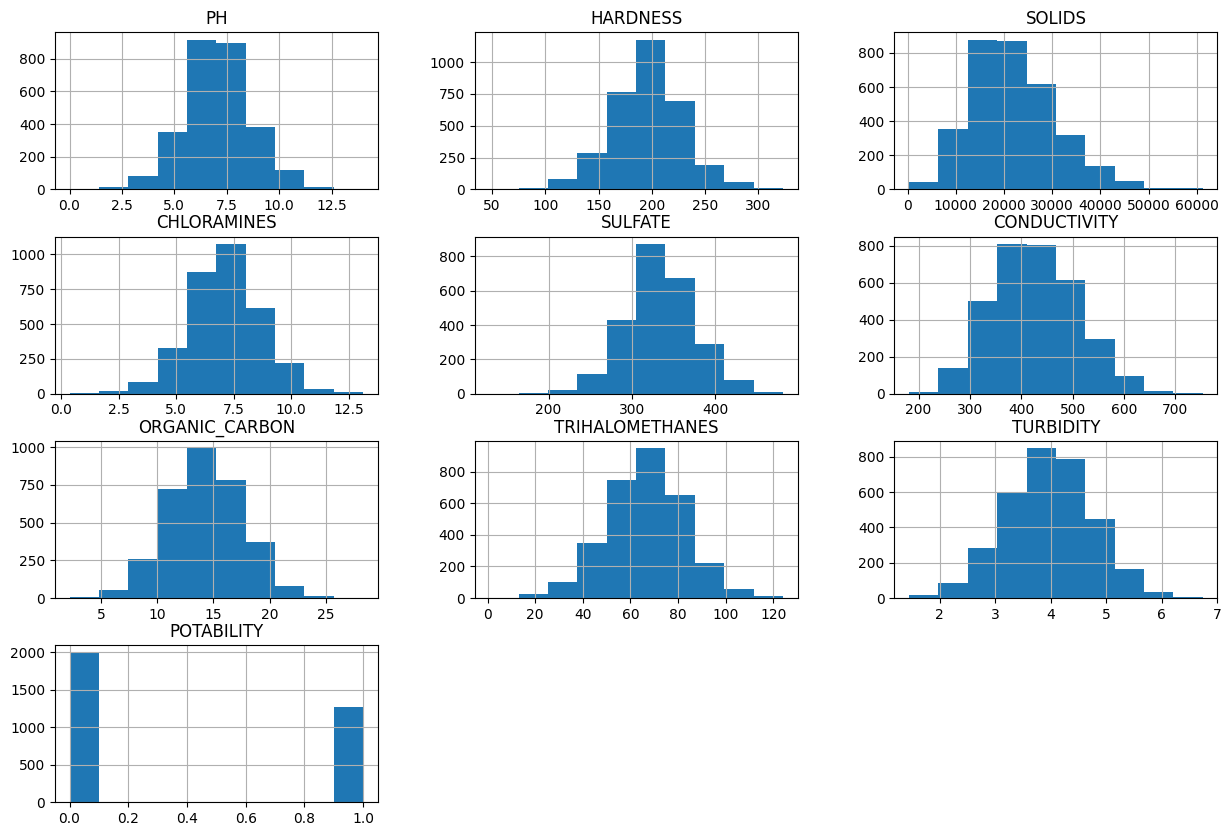

In [12]:
df.hist(figsize=(15,10))

plt.show()

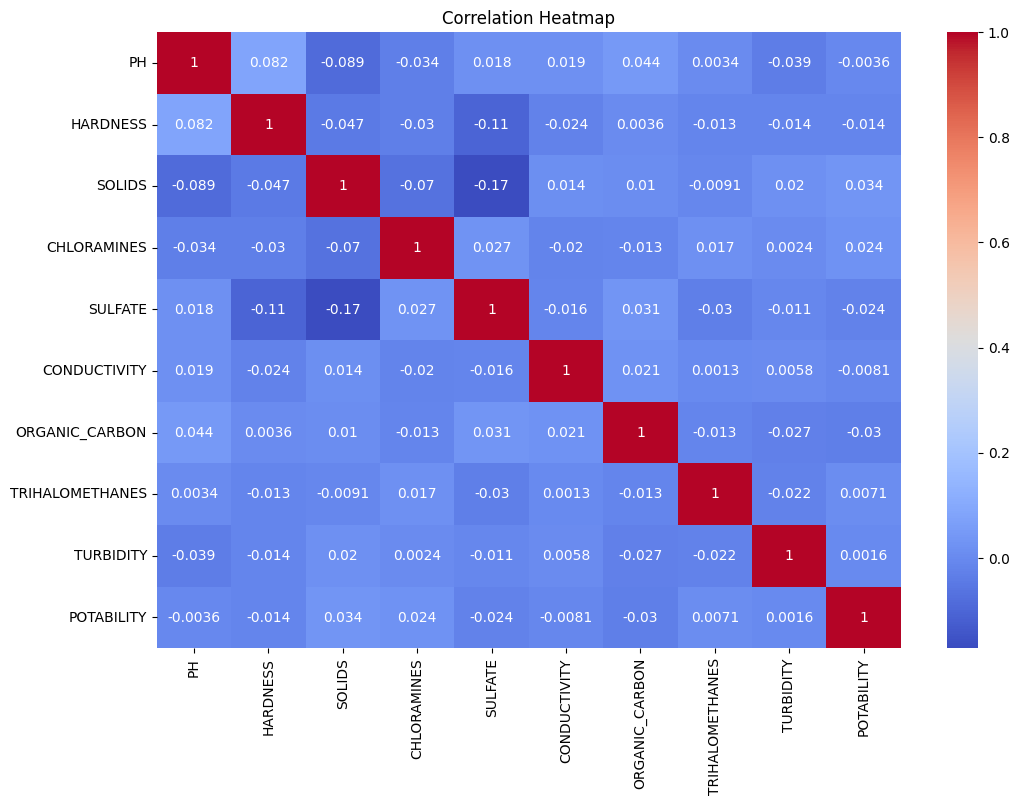

In [13]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')

plt.show()

In [14]:
X = df.drop('POTABILITY', axis=1)

y = df['POTABILITY']

In [15]:
imputer = SimpleImputer(strategy='median')

X_imputed = imputer.fit_transform(X)

X = pd.DataFrame(X_imputed, columns=X.columns)

X.isnull().sum()

,0
PH,0
HARDNESS,0
SOLIDS,0
CHLORAMINES,0
SULFATE,0
CONDUCTIVITY,0
ORGANIC_CARBON,0
TRIHALOMETHANES,0
TURBIDITY,0


In [16]:
for col in X.columns:

    Q1 = X[col].quantile(0.25)

    Q3 = X[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR

    upper = Q3 + 1.5 * IQR

    X[col] = np.where(X[col] < lower, lower, X[col])

    X[col] = np.where(X[col] > upper, upper, X[col])

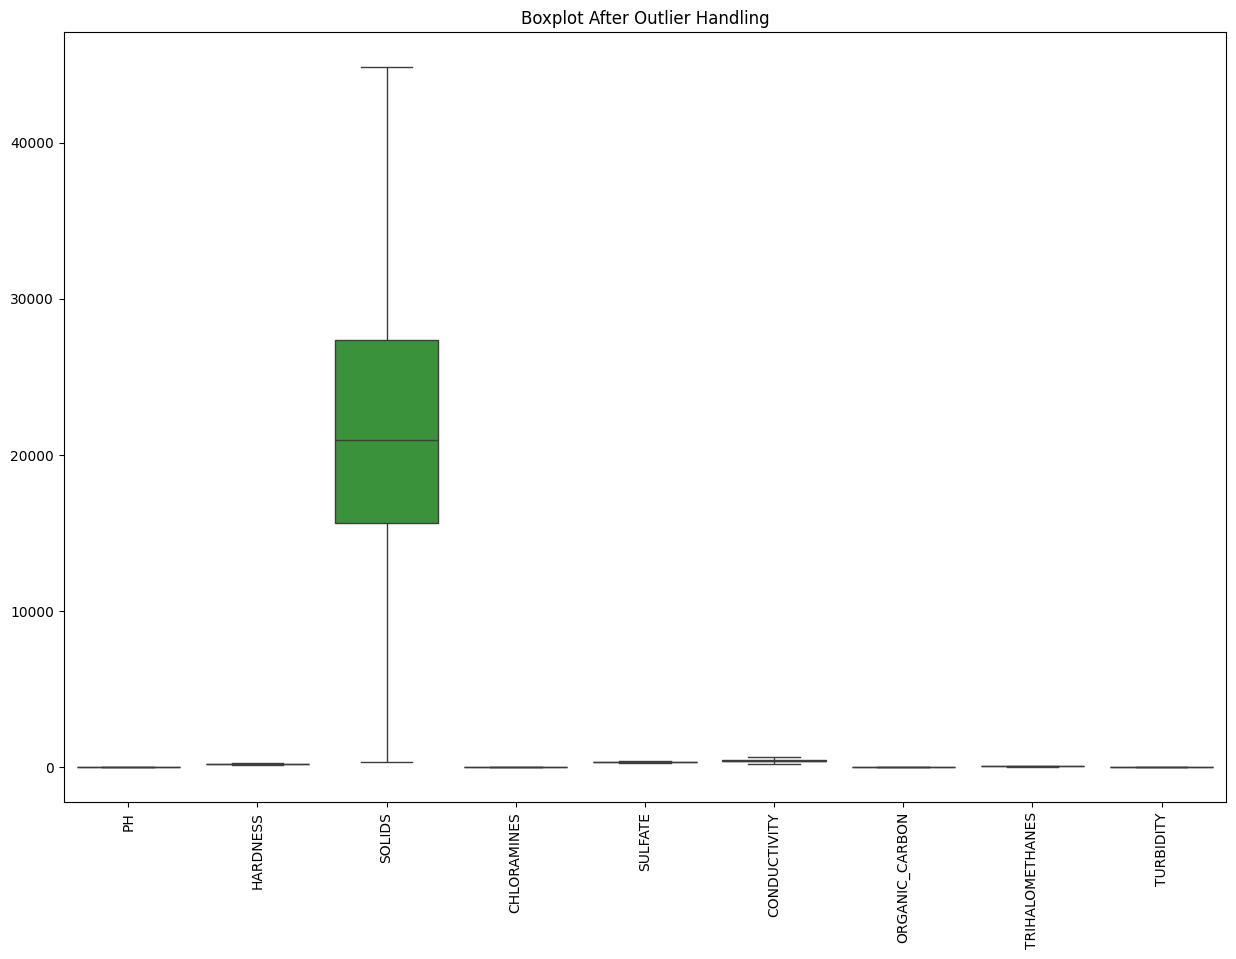

In [17]:
plt.figure(figsize=(15,10))

sns.boxplot(data=X)

plt.xticks(rotation=90)

plt.title('Boxplot After Outlier Handling')

plt.show()

In [19]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled.head()

,PH,HARDNESS,SOLIDS,CHLORAMINES,SULFATE,CONDUCTIVITY,ORGANIC_CARBON,TRIHALOMETHANES,TURBIDITY
0,-0.026484,0.265461,-0.135691,0.115564,1.098554,1.715401,-1.187299,1.327709,-1.292657
1,-2.304373,-2.091993,-0.387249,-0.315144,-0.017243,2.070162,0.272685,-0.652415,0.687944
2,0.742334,0.869786,-0.238325,1.395235,-0.017243,-0.093403,0.786278,-0.000744,-1.173116
3,0.899837,0.561689,0.007136,0.607257,0.732414,-0.780410,1.263149,2.189888,0.852978
4,1.461021,-0.477657,-0.463030,-0.372561,-0.739361,-0.344116,-0.828861,-2.223698,0.139720


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [21]:
svc_model = SVC(
    kernel='rbf',
    C=1,
    gamma='scale'
)

svc_model.fit(X_train, y_train)

SVC(C=1)

In [22]:
y_pred = svc_model.predict(X_test)

In [23]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.6646341463414634


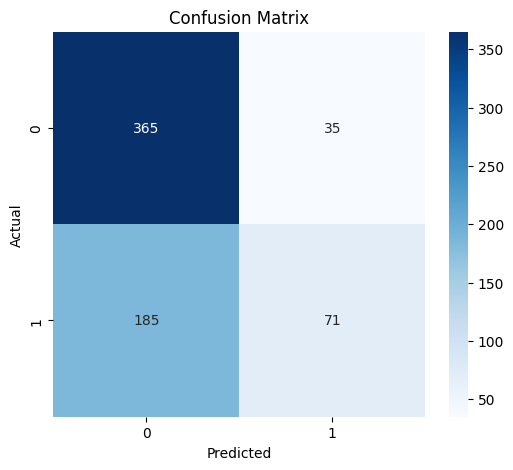

In [24]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.title('Confusion Matrix')

plt.show()

In [25]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.66      0.91      0.77       400
           1       0.67      0.28      0.39       256

    accuracy                           0.66       656
   macro avg       0.67      0.59      0.58       656
weighted avg       0.67      0.66      0.62       656



In [27]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.001],
    'kernel': ['rbf']
}

grid = GridSearchCV(
    SVC(),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters :", grid.best_params_)

print("Best Cross Validation Score :", grid.best_score_)

Best Parameters : {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
Best Cross Validation Score : 0.6786259541984733


In [28]:
best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_test)

In [29]:
final_accuracy = accuracy_score(y_test, y_pred_best)

print("Final Accuracy :", final_accuracy)

Final Accuracy : 0.6219512195121951


In [30]:
print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       0.66      0.80      0.72       400
           1       0.52      0.34      0.42       256

    accuracy                           0.62       656
   macro avg       0.59      0.57      0.57       656
weighted avg       0.60      0.62      0.60       656



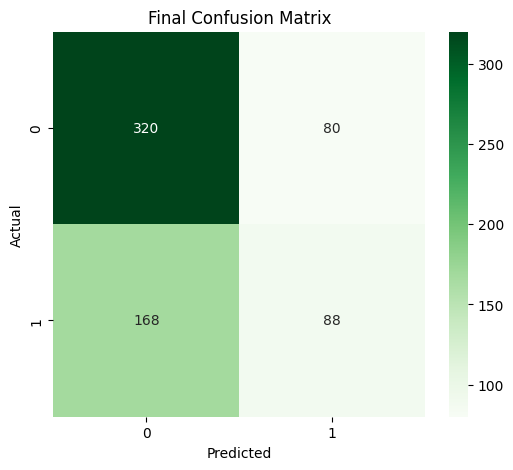

In [31]:
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.title('Final Confusion Matrix')

plt.show()